# Forecasting Hurricane-Relevant Weather Metrics with a Multi-Output MLP

Predicts four hurricane-relevant metrics — rainfall, wind speed, wind direction and surface air pressure — **seven days ahead** of the current date, from a 1.4M-row NASA reanalysis dataset.

Wind direction is circular, so it is encoded as sine/cosine pairs for training and recovered with `arctan2`, giving five model outputs for four physical targets.


## Library Import

In [1]:
import os
import random
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

## Load Dataset and Reduce Dimensions

In [2]:
# ---------------------------------------------------------------------------
# Set DATA_DIR to the folder holding the dataset: one sub-directory per
# variable, each with daily CSVs of 3-hourly readings (data_hour_0 ... data_hour_21).
# ---------------------------------------------------------------------------
d_path = os.environ.get("DATA_DIR", "data/hurricane")

#sub directories for iteration
dirs =  ['Rainf_tavg', 'Wind_f_inst', 'Wind_dir_p1000', 'Psurf_f_inst',
    'SWdown_f_tavg', 'LWdown_f_tavg']
h_cols = [f"data_hour_{h}" for h in range(0,24,3)]  
raw_df = pd.DataFrame()

print("Data Load Begins")

for dire in dirs:
    dir_path = f"{d_path}/{dire}"
    me_list = []
    for fname in os.listdir(dir_path):
        if fname.endswith('.csv'):
            tmp_df = pd.read_csv(f"{dir_path}/{fname}")
            me_list.append(tmp_df)
    merge_df = pd.concat(me_list)
    merge_df[f"{dire}_mean"] = merge_df[h_cols].mean(axis=1) #calculate the average for values to reduce dimensionality
    if raw_df.empty:
        raw_df = merge_df[['latitude', 'longitude','year','month','day', f"{dire}_mean"]]
    else:
        raw_df = raw_df.merge(merge_df[['latitude', 'longitude','year','month','day', f"{dire}_mean"]], 
                          on=['latitude', 'longitude', 'year', 'month', 'day'], 
                              how='inner')
    del merge_df #free up memory

print("Data Load Ends")
print(f"Shape of raw dataset: {raw_df.shape}")
print(f"\nFirst five rows in raw dataset: \n{raw_df.head()}")

Data Load Begins
Data Load Ends
Shape of raw dataset: (1404783, 11)

First five rows in raw dataset: 
   latitude  longitude  year  month  day  Rainf_tavg_mean  Wind_f_inst_mean  \
0     -43.5      146.5  2024      7    1     0.000000e+00          3.837224   
1     -42.5      -73.5  2024      7    1     7.264314e-08          2.244576   
2     -42.5      145.5  2024      7    1     0.000000e+00          0.970868   
3     -41.5      -73.5  2024      7    1     1.286176e-04          1.935752   
4     -40.5      -64.5  2024      7    1     0.000000e+00          4.178222   

   Wind_dir_p1000_mean  Psurf_f_inst_mean  SWdown_f_tavg_mean  \
0            15.905000       100659.11250           56.556975   
1           -55.850000        99362.86375           44.378835   
2            57.247500        99318.56875           60.199328   
3           -88.352857        99901.45625           52.810463   
4            29.905000       100768.93750           81.155387   

   LWdown_f_tavg_mean  
0       

## Feature Engineering

In [3]:
#duplicate and null check
print(f"Number of duplicate rows in raw dataset: {raw_df.duplicated().sum()}") 
print(f"Number of NaN values in each column: \n{raw_df.isnull().sum()}")

Number of duplicate rows in raw dataset: 0
Number of NaN values in each column: 
latitude               0
longitude              0
year                   0
month                  0
day                    0
Rainf_tavg_mean        0
Wind_f_inst_mean       0
Wind_dir_p1000_mean    0
Psurf_f_inst_mean      0
SWdown_f_tavg_mean     0
LWdown_f_tavg_mean     0
dtype: int64


In [4]:
#create a copy of raw dataset so that it remains untouched
pro_df = raw_df.copy()

#create date column
pro_df.insert(5, "date", pd.to_datetime(pro_df[['year', 'month', 'day']]))
print(f"Column types in processed dataset: \n{pro_df.dtypes}")

Column types in processed dataset: 
latitude                      float64
longitude                     float64
year                            int64
month                           int64
day                             int64
date                   datetime64[ns]
Rainf_tavg_mean               float64
Wind_f_inst_mean              float64
Wind_dir_p1000_mean           float64
Psurf_f_inst_mean             float64
SWdown_f_tavg_mean            float64
LWdown_f_tavg_mean            float64
dtype: object


In [5]:
#target column labels
t_cols = ['Rainf_tavg_mean', 'Wind_f_inst_mean', 
                'Wind_dir_p1000_mean', 'Psurf_f_inst_mean']

#target df with feature values 
t_df = pro_df[['latitude', 'longitude', 'date'] + t_cols].copy()

#make target dates as T + 7
t_df['date'] = t_df['date'] - pd.Timedelta(days=7)

#rename columns with target_
t_df = t_df.rename(columns={col: f"target_{col}" for col in t_cols})

#merge back with pro_df on latitude, longitude and date
pro_df = pd.merge(pro_df, t_df, on=['latitude', 'longitude', 'date'], how='left')
pro_df.head()

,latitude,longitude,year,month,day,date,Rainf_tavg_mean,Wind_f_inst_mean,Wind_dir_p1000_mean,Psurf_f_inst_mean,SWdown_f_tavg_mean,LWdown_f_tavg_mean,target_Rainf_tavg_mean,target_Wind_f_inst_mean,target_Wind_dir_p1000_mean,target_Psurf_f_inst_mean
0,-43.5,146.5,2024,7,1,2024-07-01,0.000000e+00,3.837224,15.905000,100659.11250,56.556975,312.009813,0.000063,2.784783,-90.71625,99597.535
1,-42.5,-73.5,2024,7,1,2024-07-01,7.264314e-08,2.244576,-55.850000,99362.86375,44.378835,294.927338,0.000000,4.124911,84.75500,100565.275
2,-42.5,145.5,2024,7,1,2024-07-01,0.000000e+00,0.970868,57.247500,99318.56875,60.199328,302.871325,NaN,NaN,NaN,NaN
3,-41.5,-73.5,2024,7,1,2024-07-01,1.286176e-04,1.935752,-88.352857,99901.45625,52.810463,314.177987,0.000000,2.627723,93.70500,101071.025
4,-40.5,-64.5,2024,7,1,2024-07-01,0.000000e+00,4.178222,29.905000,100768.93750,81.155387,297.577350,0.000000,4.090886,-27.60000,102280.575


In [6]:
#check before dropping NaNs
print(f"Number of NaN values in each column: \n{pro_df.isnull().sum()}")

Number of NaN values in each column: 
latitude                           0
longitude                          0
year                               0
month                              0
day                                0
date                               0
Rainf_tavg_mean                    0
Wind_f_inst_mean                   0
Wind_dir_p1000_mean                0
Psurf_f_inst_mean                  0
SWdown_f_tavg_mean                 0
LWdown_f_tavg_mean                 0
target_Rainf_tavg_mean        489650
target_Wind_f_inst_mean       489650
target_Wind_dir_p1000_mean    489650
target_Psurf_f_inst_mean      489650
dtype: int64


In [7]:
#drop nans
pro_df = pro_df.dropna().reset_index(drop=True)

In [8]:
#check after dropping NaNs
print(f"Number of NaN values in each column of dataset: \n{pro_df.isnull().sum()}")
print(f"\nShape of final dataset before training: {pro_df.shape}")

Number of NaN values in each column of dataset: 
latitude                      0
longitude                     0
year                          0
month                         0
day                           0
date                          0
Rainf_tavg_mean               0
Wind_f_inst_mean              0
Wind_dir_p1000_mean           0
Psurf_f_inst_mean             0
SWdown_f_tavg_mean            0
LWdown_f_tavg_mean            0
target_Rainf_tavg_mean        0
target_Wind_f_inst_mean       0
target_Wind_dir_p1000_mean    0
target_Psurf_f_inst_mean      0
dtype: int64

Shape of final dataset before training: (915133, 16)


In [9]:
#sine/cosine transformation of feature wind direction due to circular nature
pro_df['Wind_dir_p1000_mean_sin'] = np.sin(np.deg2rad(pro_df['Wind_dir_p1000_mean']))
pro_df['Wind_dir_p1000_mean_cos'] = np.cos(np.deg2rad(pro_df['Wind_dir_p1000_mean']))
pro_df = pro_df.drop(columns=['Wind_dir_p1000_mean'])

In [10]:
#sine/cosine transformation of label wind direction due to circular nature
pro_df['target_Wind_dir_p1000_mean_sin'] = np.sin(np.deg2rad(pro_df['target_Wind_dir_p1000_mean']))
pro_df['target_Wind_dir_p1000_mean_cos'] = np.cos(np.deg2rad(pro_df['target_Wind_dir_p1000_mean']))
pro_df = pro_df.drop(columns=['target_Wind_dir_p1000_mean'])

In [11]:
#targets array creation
targs = np.array(pro_df[[col for col in pro_df.columns if col.startswith('target_')]], 
                      dtype=np.float32)
#feature array creation
feats = np.array(pro_df[[col for col in pro_df.columns if not col.startswith('target_') and col != 'date']], 
                      dtype=np.float32)

print(f"Shape of features: {feats.shape}")
print(f"Shape of targets: {targs.shape}")

Shape of features: (915133, 12)
Shape of targets: (915133, 5)


## Train-Test Splitting

In [12]:
#train-test 70(Training)-30(Validation + Test) split for MLP Modelling. 
feat_train, feat_rem, targs_train, targs_rem = train_test_split(feats, targs, test_size=0.3, train_size=0.7,
                                 random_state=1, shuffle=True)
feat_val, feat_test, targs_val, targs_test = train_test_split(feat_rem, targs_rem, test_size=0.5, train_size=0.5,
                                 random_state=1, shuffle=True)

print("Number of Instances")
print(f"Training: Features = {feat_train.shape[0]}, Target = {targs_train.shape[0]}")
print(f"Validation: Features = {feat_val.shape[0]}, Target = {targs_val.shape[0]}")
print(f"Test: Features = {feat_test.shape[0]}, Target = {targs_test.shape[0]}")

Number of Instances
Training: Features = 640593, Target = 640593
Validation: Features = 137270, Target = 137270
Test: Features = 137270, Target = 137270


## Normalize the Train-Test Split

In [13]:
#scale/normalize features and targets using standard scaler
feat_scaler = StandardScaler()
targs_scaler = StandardScaler()

feat_scaler.fit(feat_train)
feat_train_s = feat_scaler.transform(feat_train)
feat_val_s = feat_scaler.transform(feat_val)
feat_test_s = feat_scaler.transform(feat_test)

targs_scaler.fit(targs_train)
targs_train_s = targs_scaler.transform(targs_train)
targs_val_s = targs_scaler.transform(targs_val)
targs_test_s = targs_scaler.transform(targs_test)

print("Mean and Standard Deviation of Training Instances:")
print(f"\nFeatures: \nMean = {feat_train_s.mean(axis=0)}, \nSD = {feat_train_s.std(axis=0)}") #12 features
print(f"\nTargets: \nMean = {targs_train_s.mean(axis=0)}, \nSD = {targs_train_s.std(axis=0)}") #5 targets

Mean and Standard Deviation of Training Instances:

Features: 
Mean = [ 1.6336791e-08 -7.5344268e-08  5.3791592e-07  2.7939643e-07
  4.6858173e-07  1.4461582e-06 -3.3113225e-09 -1.2356514e-10
  1.4434713e-07  1.0130295e-08  1.4884390e-08 -2.0307300e-09], 
SD = [0.9995084  0.9998827  0.9996611  1.0002259  0.99961776 0.99894035
 0.9998789  0.9997806  0.9999355  0.99985904 0.99992335 0.99987   ]

Targets: 
Mean = [ 2.9324908e-06 -1.6272079e-08  1.8405997e-08  6.3663963e-09
 -2.9020712e-09], 
SD = [0.9984849 0.9998733 0.9997749 1.0000472 0.9998744]


## MLP Initialisations

In [14]:
#MLP model class initialisations
class three_layer_hurrMLP(nn.Module):
    def __init__(self,
                 input_size,
                 hidden_layer_sizes,
                 output_size,
                 drop_rate):
        super().__init__()
        self.hidden_l1 = nn.Linear(input_size, hidden_layer_sizes[0])
        self.relu_l1 = nn.ReLU()
        self.dropout_l1 = nn.Dropout(p=drop_rate)
        
        self.hidden_l2 = nn.Linear(hidden_layer_sizes[0], hidden_layer_sizes[1])
        self.relu_l2 = nn.ReLU()
        self.dropout_l2 = nn.Dropout(p=drop_rate)
        
        self.output_l3 = nn.Linear(hidden_layer_sizes[1], output_size)


    def forward(self, inputs):
        out = self.hidden_l1(inputs)
        out = self.relu_l1(out)
        out = self.dropout_l1(out)
        
        out = self.hidden_l2(out)
        out = self.relu_l2(out)
        out = self.dropout_l2(out)
        
        out = self.output_l3(out)
        return out

#class initialisation to convert to tensor dataset
class hurr_dataset(Dataset):
    def __init__(self, feats, targs):
        self.features  = torch.tensor(feats,  dtype=torch.float32)
        self.targets = torch.tensor(targs, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

In [15]:
#reproducibility
random.seed(1)
np.random.seed(1)
torch.manual_seed(1)

#hypeparameters
in_size = feat_train_s.shape[1]
hid_size = [128, 64]
out_size = targs_train_s.shape[1]
d_rate = 0.3
l_rate = 0.001
b_size = 64
max_epoch = 100

#setup dataloaders
train_set = hurr_dataset(feat_train_s, targs_train_s)
val_set = hurr_dataset(feat_val_s, targs_val_s)
test_set = hurr_dataset(feat_test_s, targs_test_s)

train_dataloader = DataLoader(train_set, batch_size=b_size)
val_dataloader = DataLoader(val_set, batch_size=len(val_set))
test_dataloader = DataLoader(test_set, batch_size=len(test_set))

hurricane_predictor = three_layer_hurrMLP(in_size, hid_size, out_size, d_rate)
print(hurricane_predictor)

three_layer_hurrMLP(
  (hidden_l1): Linear(in_features=12, out_features=128, bias=True)
  (relu_l1): ReLU()
  (dropout_l1): Dropout(p=0.3, inplace=False)
  (hidden_l2): Linear(in_features=128, out_features=64, bias=True)
  (relu_l2): ReLU()
  (dropout_l2): Dropout(p=0.3, inplace=False)
  (output_l3): Linear(in_features=64, out_features=5, bias=True)
)


## Model Training

In [16]:
#MSE loss function initialisation
loss_func = nn.MSELoss()

#optimizer initialisation
opt = optim.Adam(hurricane_predictor.parameters(), lr=l_rate)

#variables for early stopping
b_epoch = 0
b_val_loss = 0
train_val_loss = []

print("Model Training Starts\n")

for epoch in range(max_epoch):
    #set model to train mode
    hurricane_predictor.train()
        
    #to calculate average training loss
    t_losses = []
    
    for batch, (f_train, t_train) in enumerate(train_dataloader):
        #optimize the gradients
        opt.zero_grad()

        #forward pass
        t_pred = hurricane_predictor(f_train)
        
        #loss calculation
        t_loss = loss_func(t_pred, t_train)
        t_losses.append(t_loss.item())

        #backward propagation and gradient update
        t_loss.backward()
        opt.step()

    #average training loss
    a_train_loss = np.mean(t_losses)
    
    
    #set model to evaluation mode
    hurricane_predictor.eval()
    
    #to calculate average validation loss
    v_losses = []   
    
    for batch, (f_val, t_val) in enumerate(val_dataloader):
        v_pred = hurricane_predictor(f_val)
        v_loss = loss_func(v_pred, t_val)
        v_losses.append(v_loss.item())

    #average validation loss
    a_val_loss = np.mean(v_losses)

    print(f"Iteration: {epoch+1}, Epoch: {epoch},   Training Loss: {a_train_loss}, Validation Loss: {a_val_loss}")   
    
    train_val_loss.append([a_train_loss, a_val_loss])
    
    #early stop check
    if epoch == 0: # first model saved as best model since it is the initial iteration
        best_model = deepcopy(hurricane_predictor)
        b_val_loss = a_val_loss
        print("Model Saved\n")
    elif a_val_loss < b_val_loss:
        b_epoch = epoch
        b_val_loss = a_val_loss
        best_model = deepcopy(hurricane_predictor)
        print("Performance Improved. Model Saved\n")

print("\nModel Training Ends")
print(f"Best model found at iteration {b_epoch+1} with validation loss of {b_val_loss}")

Model Training Starts

Iteration: 1, Epoch: 0,   Training Loss: 0.7803994881165969, Validation Loss: 0.74517422914505
Model Saved

Iteration: 2, Epoch: 1,   Training Loss: 0.7626527979984865, Validation Loss: 0.7370200157165527
Performance Improved. Model Saved

Iteration: 3, Epoch: 2,   Training Loss: 0.7573533741089252, Validation Loss: 0.7301037907600403
Performance Improved. Model Saved

Iteration: 4, Epoch: 3,   Training Loss: 0.7546333548876194, Validation Loss: 0.729051947593689
Performance Improved. Model Saved

Iteration: 5, Epoch: 4,   Training Loss: 0.7527005951810669, Validation Loss: 0.7265143394470215
Performance Improved. Model Saved

Iteration: 6, Epoch: 5,   Training Loss: 0.7512873921152595, Validation Loss: 0.723302960395813
Performance Improved. Model Saved

Iteration: 7, Epoch: 6,   Training Loss: 0.7497651296985018, Validation Loss: 0.7239455580711365
Iteration: 8, Epoch: 7,   Training Loss: 0.7489978738836237, Validation Loss: 0.719828724861145
Performance Improv

## Plot Learning Curve

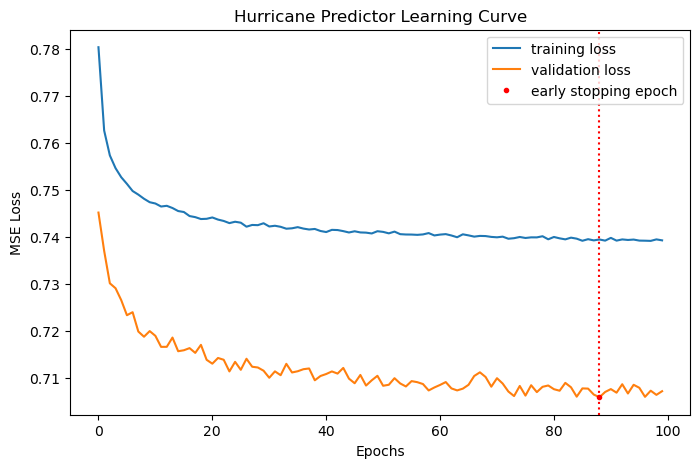

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
losses = np.array(train_val_loss)
ax.plot(losses[:, 0], label='training loss')
ax.plot(losses[:, 1], label='validation loss')
ax.plot(b_epoch, losses[b_epoch, 1], 'r.', label='early stopping epoch')
ax.axvline(b_epoch, color='red', linestyle=':')
plt.title('Hurricane Predictor Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend(loc='upper right')
plt.show()

## Best Model Testing

In [18]:
#set model to evaluation mode for testing
best_model.eval()
te_preds = []
te_actuals = []
for batch, (f_test, t_test) in enumerate(test_dataloader):
    te_pred = best_model.forward(f_test)
    te_preds.append(te_pred.detach().numpy())
    te_actuals.append(t_test.detach().numpy())

#initialise target column names
targs_col = ['RainFall', 'WindSpeed', 'SurfacePressure', 'WindDirection_sin', 'WindDirection_cos']

#store predictions and actuals as dataframe
preds_df = pd.DataFrame(np.vstack(te_preds), columns=targs_col)
actuals_df = pd.DataFrame(np.vstack(te_actuals), columns=targs_col)

#inverse transform to original value
predsinv_df = pd.DataFrame(targs_scaler.inverse_transform(preds_df), columns=targs_col)
actualsinv_df = pd.DataFrame(targs_scaler.inverse_transform(actuals_df), columns=targs_col)

#inverse transform sin/cos wind direction to degrees
predsinv_df['WindDirection'] = np.rad2deg(np.arctan2(predsinv_df['WindDirection_sin'], 
                                                   predsinv_df['WindDirection_cos'])) % 360

actualsinv_df['WindDirection'] = np.rad2deg(np.arctan2(actualsinv_df['WindDirection_sin'], 
                                                     actualsinv_df['WindDirection_cos'])) % 360

#drop unwanted sin/cos columns 
predsinv_df   = predsinv_df.drop(columns=['WindDirection_sin', 'WindDirection_cos'])
actualsinv_df = actualsinv_df.drop(columns=['WindDirection_sin', 'WindDirection_cos'])

#RMSE of predictions
print("Root Mean Square Error on Best Model\n")
for col in predsinv_df.columns:
    print(f"{col}: {root_mean_squared_error(actualsinv_df[col], predsinv_df[col]):.4f}")

Root Mean Square Error on Best Model

RainFall: 0.0001
WindSpeed: 1.5919
SurfacePressure: 588.5651
WindDirection: 163.0287


## Plot Predicted vs Actual Values

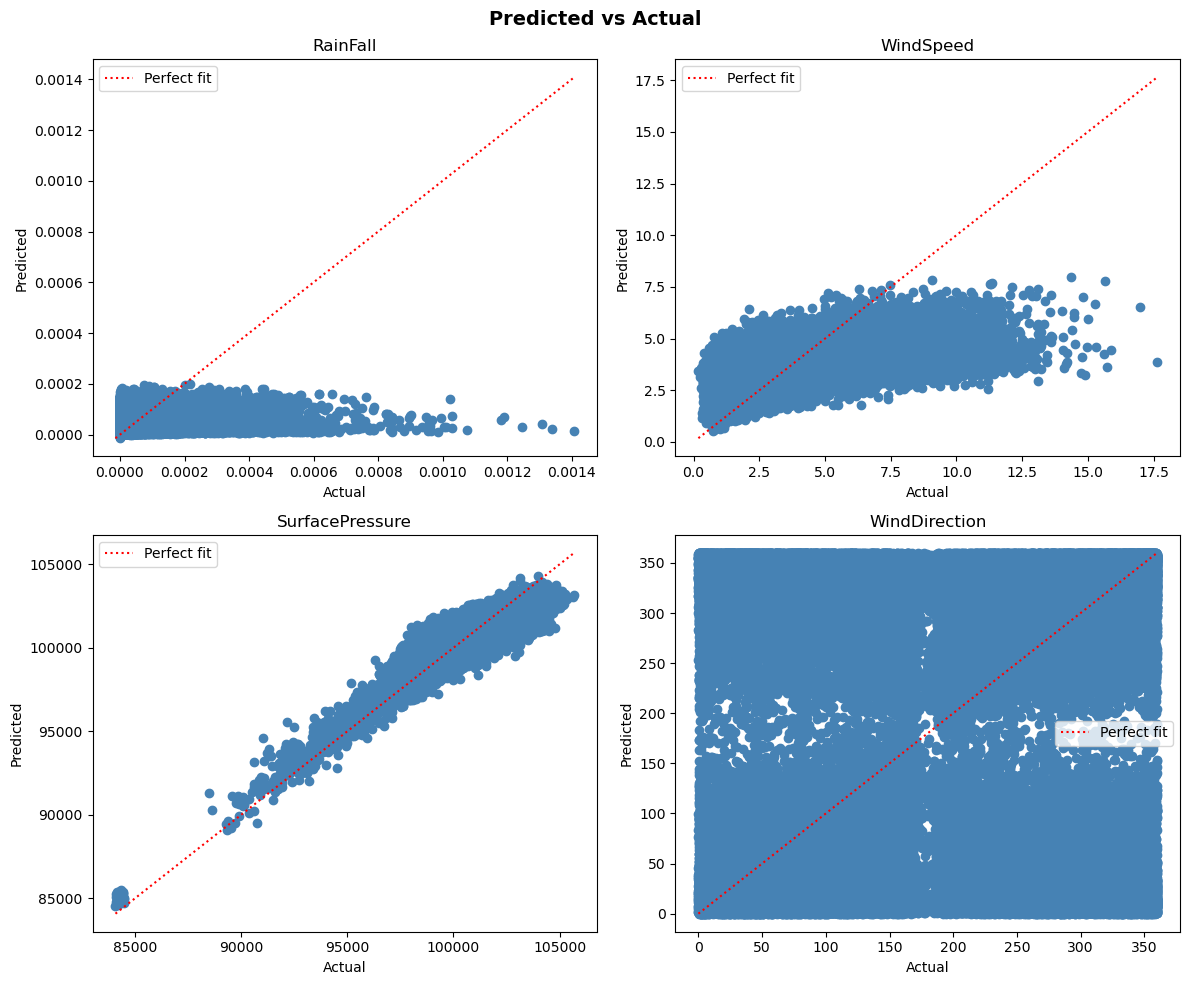

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(predsinv_df.columns):
    ax = axes[i]
    ax.scatter(actualsinv_df[col], predsinv_df[col], color='steelblue')

    #perfect fit line
    min_val = min(actualsinv_df[col].min(), predsinv_df[col].min())
    max_val = max(actualsinv_df[col].max(), predsinv_df[col].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r:', linewidth=1.5, label='Perfect fit')
    
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{col}')
    ax.legend()

plt.suptitle('Predicted vs Actual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Output Predictions to CSV

In [20]:
#output to csv
outcsv_df = pd.DataFrame()

#build csv dataframe
for true_col, pred_col in zip(actualsinv_df.columns, predsinv_df.columns):
    outcsv_df[f"{true_col}_true"] = actualsinv_df[true_col]
    outcsv_df[f"{pred_col}_predicted"] = predsinv_df[pred_col]

#clip negative values to 0
outcsv_df['RainFall_true']      = outcsv_df['RainFall_true'].clip(lower=0)
outcsv_df['RainFall_predicted'] = outcsv_df['RainFall_predicted'].clip(lower=0)
    
outcsv_df.to_csv("predictions.csv", index=False)
print("A sneak into prediction list:\n")
print(outcsv_df.head())

A sneak into prediction list:

   RainFall_true  RainFall_predicted  WindSpeed_true  WindSpeed_predicted  \
0       0.000003            0.000004        2.178429             3.621566   
1       0.000000            0.000006        7.090948             3.992530   
2       0.000000            0.000010        2.670729             4.019074   
3       0.000000            0.000013        4.172024             3.736423   
4       0.000006            0.000016        1.807645             3.172872   

   SurfacePressure_true  SurfacePressure_predicted  WindDirection_true  \
0         101305.609375              101475.859375           62.463741   
1          99993.781250              101260.523438          177.469986   
2         100147.242188              101312.476562          325.975006   
3         100566.296875              101160.507812           95.899994   
4         100220.539062              100398.734375          223.617508   

   WindDirection_predicted  
0                29.681118  
1  